[*********************100%***********************]  1 of 1 completed


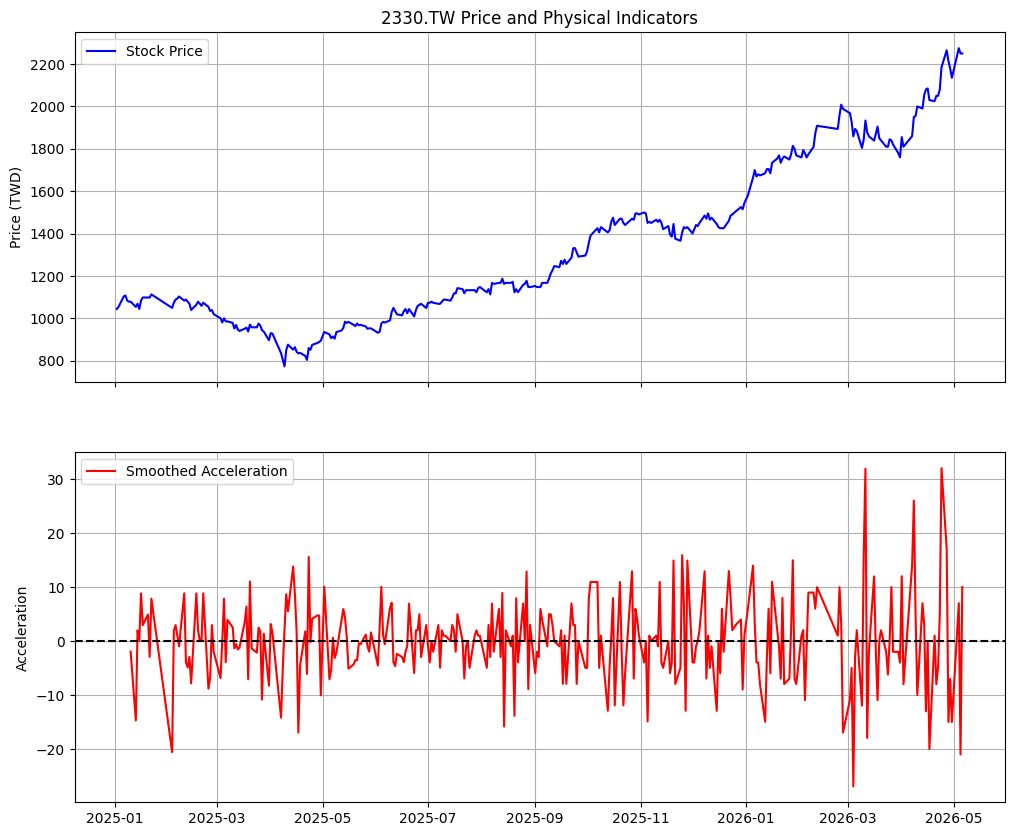

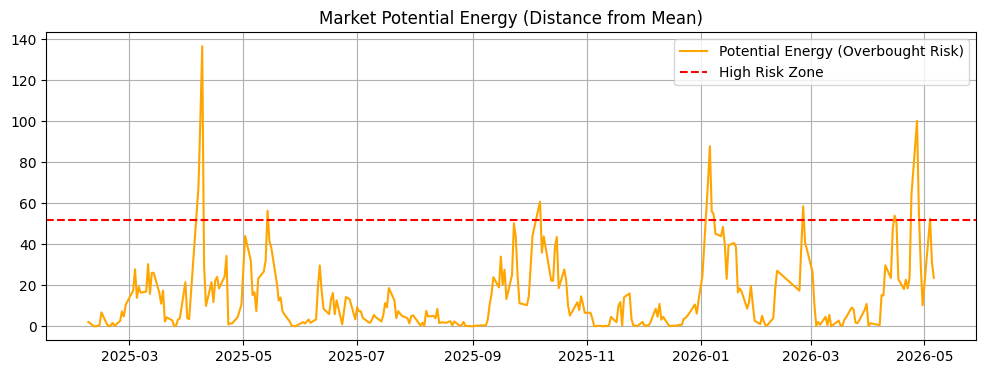

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 抓取台股數據 (以台積電 2330 為例)
stock_id = "2330.TW"
df = yf.download(stock_id, start="2025-01-01")

# 2. 物理指標計算
# 假設時間間隔 dt = 1 天
# 速度 (Velocity) = 價格的一階差分
df['Velocity'] = df['Close'].diff()

# 加速度 (Acceleration) = 速度的一階差分 (即價格的二階差分)
df['Acceleration'] = df['Velocity'].diff()

# 3. 數據平滑化 (物理上的低通濾波，減少市場雜訊)
# 股市雜訊太多，直接看加速度會很亂，我們用 5 天移動平均來平滑
df['Smooth_Accel'] = df['Acceleration'].rolling(window=5).mean()

# 4. 繪圖與視覺化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 上圖：收盤價
ax1.plot(df.index, df['Close'], label='Stock Price', color='blue')
ax1.set_title(f'{stock_id} Price and Physical Indicators')
ax1.set_ylabel('Price (TWD)')
ax1.legend()
ax1.grid(True)

# 下圖：平滑後的加速度
# 當加速度 > 0 且由負轉正，在力學上代表「推力增加」
ax2.plot(df.index, df['Smooth_Accel'], label='Smoothed Acceleration', color='red')
ax2.axhline(0, color='black', linestyle='--') # 零軸
ax2.set_ylabel('Acceleration')
ax2.legend()
ax2.grid(True)

plt.show()


# 5. 計算彈性位能 (以 20 日均線為平衡位置)
# 使用 .squeeze() 確保抓出來的是 Series 而不是 DataFrame
close_price = df['Close'].squeeze() 
df_ma20 = close_price.rolling(window=20).mean()

# 位能 U = 1/2 * k * x^2，這裡假設 k=1
# 計算 (股價 - 均線) / 均線 的百分比偏離度
dist_percent = (close_price - df_ma20) / df_ma20 * 100
df['Potential_Energy'] = 0.5 * (dist_percent**2)

# 6. 新增一個圖表呈現位能
plt.figure(figsize=(12, 4))
# 同樣使用 squeeze 確保繪圖數據正確
plt.plot(df.index, df['Potential_Energy'].squeeze(), label='Potential Energy (Overbought Risk)', color='orange')

# 計算風險線 (平均值 + 2倍標準差)
mean_pe = df['Potential_Energy'].mean().item() # .item() 轉為數值
std_pe = df['Potential_Energy'].std().item()
plt.axhline(mean_pe + std_pe * 2, color='red', linestyle='--', label='High Risk Zone')

plt.title('Market Potential Energy (Distance from Mean)')
plt.legend()
plt.grid(True)
plt.show()


In [2]:
# 取得最新的數值
latest_accel = df['Smooth_Accel'].iloc[-1]
latest_pe = df['Potential_Energy'].iloc[-1]
risk_threshold = mean_pe + std_pe * 2

print("\n--- 物理老師股市診斷報告 ---")
if latest_accel > 0 and latest_pe < risk_threshold:
    print("狀態：【穩定加速區】")
    print("分析：動力充足且尚未過熱，就像剛起步的賽車，具備上漲潛力。")
elif latest_accel > 0 and latest_pe >= risk_threshold:
    print("狀態：【極度過熱區】")
    print("分析：雖然動力還在，但彈簧已拉到極限，隨時可能產生劇烈回彈，請勿追高。")
elif latest_accel < 0 and latest_pe < 1.0:
    print("狀態：【能量耗盡區】")
    print("分析：球已經快飛不動了，且就在平衡位置附近，市場進入震盪或觀望。")
else:
    print("狀態：【盤整或反轉中】")
    print("分析：目前訊號較雜，建議結合其他物理指標觀察。")


--- 物理老師股市診斷報告 ---
狀態：【穩定加速區】
分析：動力充足且尚未過熱，就像剛起步的賽車，具備上漲潛力。


[*********************100%***********************]  1 of 1 completed


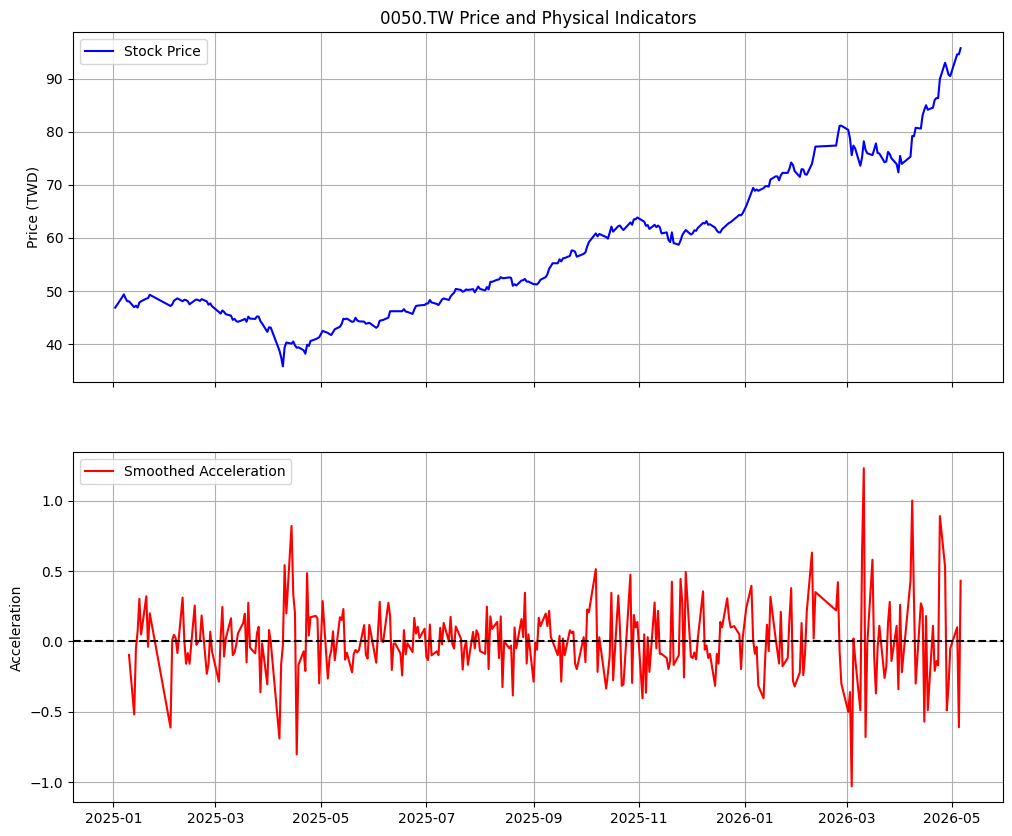

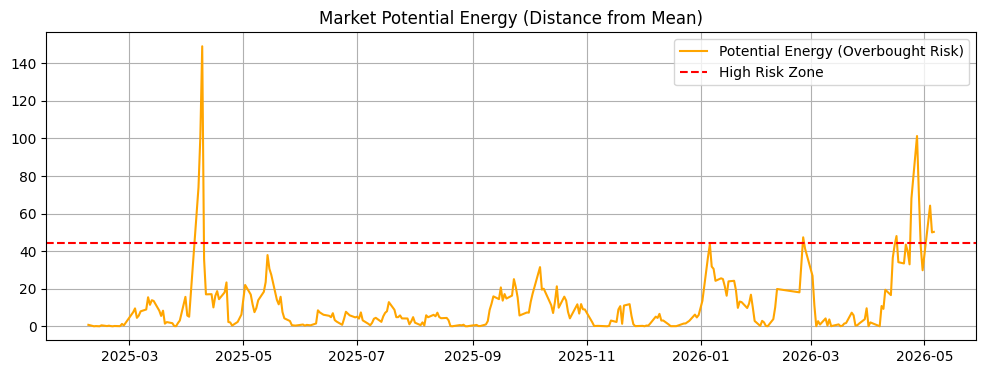


--- 物理老師股市診斷報告 ---
狀態：【極度過熱區】
分析：雖然動力還在，但彈簧已拉到極限，隨時可能產生劇烈回彈，請勿追高。


In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 抓取台股數據 (以台積電 2330 為例)
stock_id = "0050.TW"
df = yf.download(stock_id, start="2025-01-01")

# 2. 物理指標計算
# 假設時間間隔 dt = 1 天
# 速度 (Velocity) = 價格的一階差分
df['Velocity'] = df['Close'].diff()

# 加速度 (Acceleration) = 速度的一階差分 (即價格的二階差分)
df['Acceleration'] = df['Velocity'].diff()

# 3. 數據平滑化 (物理上的低通濾波，減少市場雜訊)
# 股市雜訊太多，直接看加速度會很亂，我們用 5 天移動平均來平滑
df['Smooth_Accel'] = df['Acceleration'].rolling(window=5).mean()

# 4. 繪圖與視覺化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 上圖：收盤價
ax1.plot(df.index, df['Close'], label='Stock Price', color='blue')
ax1.set_title(f'{stock_id} Price and Physical Indicators')
ax1.set_ylabel('Price (TWD)')
ax1.legend()
ax1.grid(True)

# 下圖：平滑後的加速度
# 當加速度 > 0 且由負轉正，在力學上代表「推力增加」
ax2.plot(df.index, df['Smooth_Accel'], label='Smoothed Acceleration', color='red')
ax2.axhline(0, color='black', linestyle='--') # 零軸
ax2.set_ylabel('Acceleration')
ax2.legend()
ax2.grid(True)

plt.show()


# 5. 計算彈性位能 (以 20 日均線為平衡位置)
# 使用 .squeeze() 確保抓出來的是 Series 而不是 DataFrame
close_price = df['Close'].squeeze() 
df_ma20 = close_price.rolling(window=20).mean()

# 位能 U = 1/2 * k * x^2，這裡假設 k=1
# 計算 (股價 - 均線) / 均線 的百分比偏離度
dist_percent = (close_price - df_ma20) / df_ma20 * 100
df['Potential_Energy'] = 0.5 * (dist_percent**2)

# 6. 新增一個圖表呈現位能
plt.figure(figsize=(12, 4))
# 同樣使用 squeeze 確保繪圖數據正確
plt.plot(df.index, df['Potential_Energy'].squeeze(), label='Potential Energy (Overbought Risk)', color='orange')

# 計算風險線 (平均值 + 2倍標準差)
mean_pe = df['Potential_Energy'].mean().item() # .item() 轉為數值
std_pe = df['Potential_Energy'].std().item()
plt.axhline(mean_pe + std_pe * 2, color='red', linestyle='--', label='High Risk Zone')

plt.title('Market Potential Energy (Distance from Mean)')
plt.legend()
plt.grid(True)
plt.show()

# 取得最新的數值
latest_accel = df['Smooth_Accel'].iloc[-1]
latest_pe = df['Potential_Energy'].iloc[-1]
risk_threshold = mean_pe + std_pe * 2

print("\n--- 物理老師股市診斷報告 ---")
if latest_accel > 0 and latest_pe < risk_threshold:
    print("狀態：【穩定加速區】")
    print("分析：動力充足且尚未過熱，就像剛起步的賽車，具備上漲潛力。")
elif latest_accel > 0 and latest_pe >= risk_threshold:
    print("狀態：【極度過熱區】")
    print("分析：雖然動力還在，但彈簧已拉到極限，隨時可能產生劇烈回彈，請勿追高。")
elif latest_accel < 0 and latest_pe < 1.0:
    print("狀態：【能量耗盡區】")
    print("分析：球已經快飛不動了，且就在平衡位置附近，市場進入震盪或觀望。")
else:
    print("狀態：【盤整或反轉中】")
    print("分析：目前訊號較雜，建議結合其他物理指標觀察。")


[**********************50%                       ]  2 of 4 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 3131.TW"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 3680.TW"}}}
$3680.TW: possibly delisted; no timezone found
$3131.TW: possibly delisted; no timezone found
[*********************100%***********************]  4 of 4 completed

2 Failed downloads:
['3680.TW', '3131.TW']: possibly delisted; no timezone found


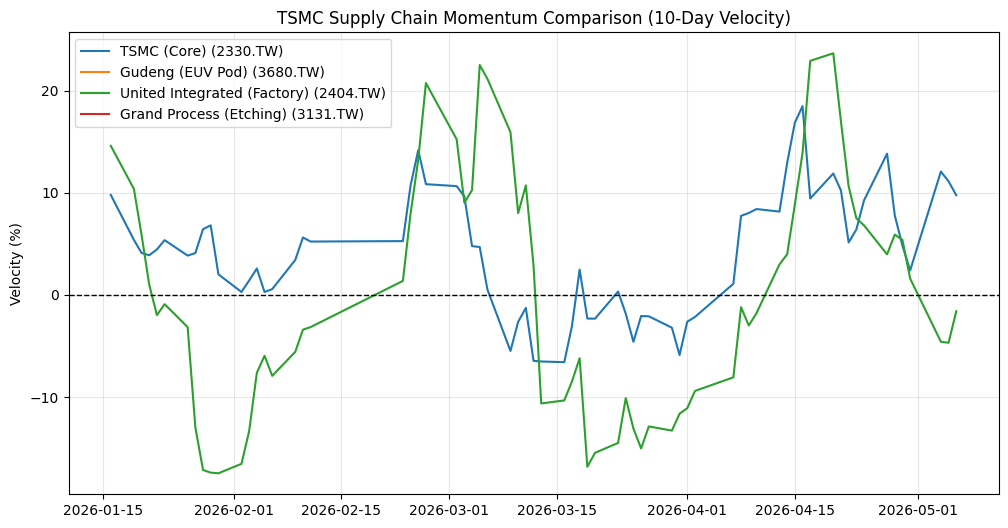

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. 定義台積電及其主要協同廠商 (範例：家登、漢唐、弘塑)
partners = {
    "2330.TW": "TSMC (Core)",
    "3680.TW": "Gudeng (EUV Pod)",
    "2404.TW": "United Integrated (Factory)",
    "3131.TW": "Grand Process (Etching)"
}

# 2. 批量抓取數據
data = yf.download(list(partners.keys()), start="2026-01-01")['Close']

# 3. 計算物理動能 (以 10 日變化率作為速度)
velocity = data.pct_change(periods=10) * 100 

# 4. 繪製「協同廠商動能分析圖」
plt.figure(figsize=(12, 6))
for stock_id, name in partners.items():
    plt.plot(velocity.index, velocity[stock_id], label=f"{name} ({stock_id})")

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title("TSMC Supply Chain Momentum Comparison (10-Day Velocity)")
plt.ylabel("Velocity (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

正在分析 TSMC (2330.TW)...


[*********************100%***********************]  1 of 1 completed


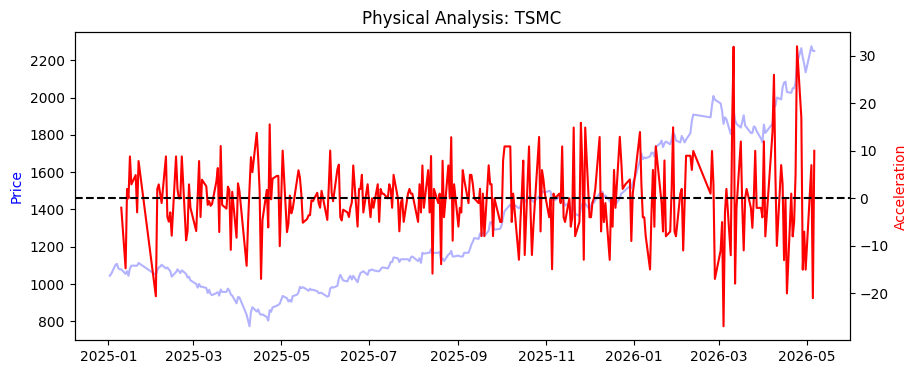

[*********************100%***********************]  1 of 1 completed

正在分析 Wanrun (CoWoS) (6187.TWO)...


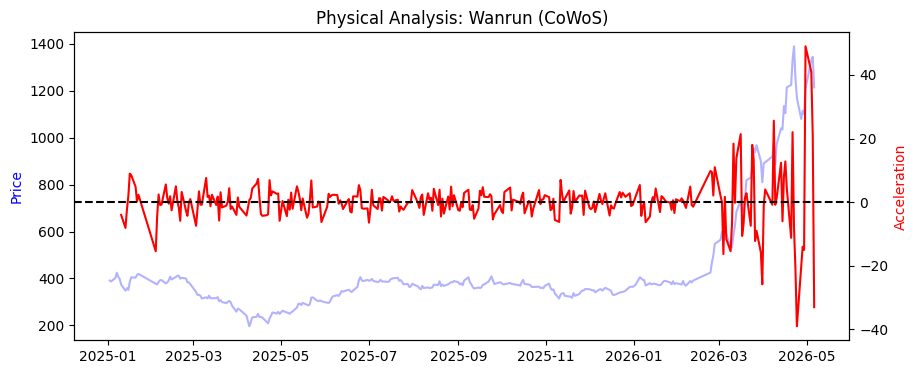

正在分析 Scientech (CoWoS) (3583.TW)...


[*********************100%***********************]  1 of 1 completed


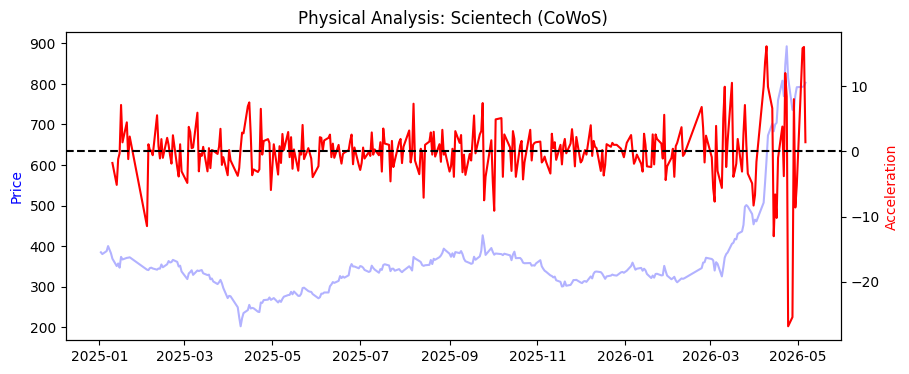

正在分析 Kinik (Diamond Disk) (1560.TW)...


[*********************100%***********************]  1 of 1 completed


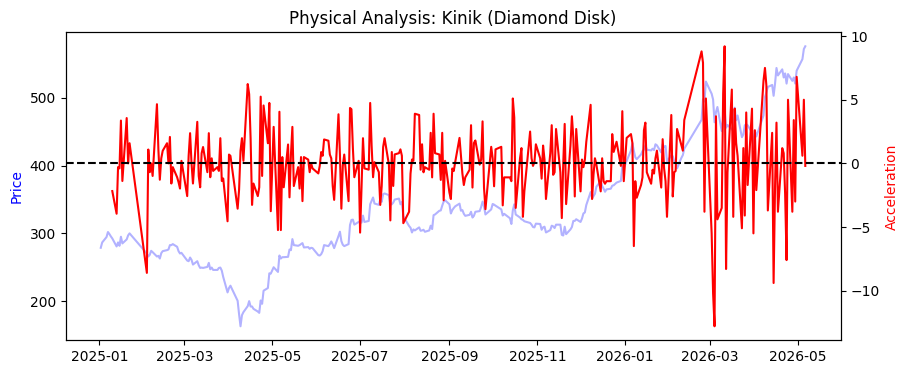

正在分析 Gudeng (EUV Pod) (3680.TWO)...


[*********************100%***********************]  1 of 1 completed


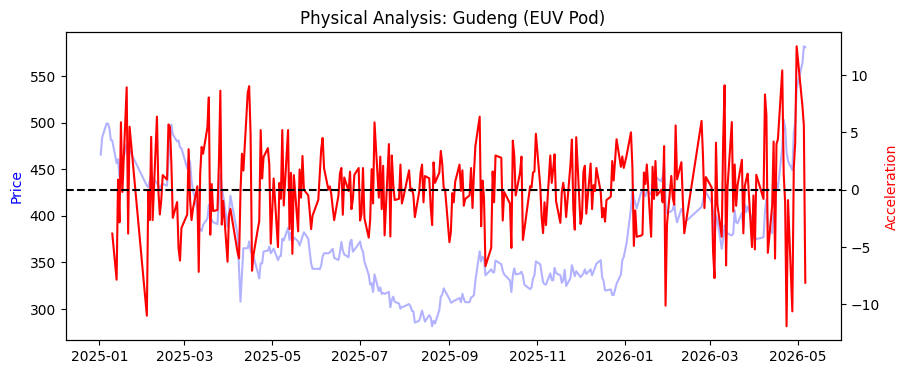

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. 定義協同廠商名單 (字典格式：名稱 -> 代號)
suppliers = {
    "TSMC": "2330.TW",
    "Wanrun (CoWoS)": "6187.TWO",
    "Scientech (CoWoS)": "3583.TW",
    "Kinik (Diamond Disk)": "1560.TW",
    "Gudeng (EUV Pod)": "3680.TWO"
}

# 2. 建立一個循環，自動為每家廠商產出圖表
for name, sid in suppliers.items():
    print(f"正在分析 {name} ({sid})...")
    
    # 抓取數據
    df = yf.download(sid, start="2025-01-01")
    if df.empty: continue
    
    # 物理指標計算 (加速度)
    close = df['Close'].squeeze()
    velocity = close.diff()
    accel = velocity.diff().rolling(window=5).mean()
    
    # 繪圖
    fig, ax1 = plt.subplots(figsize=(10, 4))
    
    # 畫股價 (左軸)
    ax1.plot(df.index, close, color='blue', alpha=0.3)
    ax1.set_ylabel('Price', color='blue')
    
    # 畫加速度 (右軸)
    ax2 = ax1.twinx() 
    ax2.plot(df.index, accel, color='red')
    ax2.axhline(0, color='black', linestyle='--')
    ax2.set_ylabel('Acceleration', color='red')
    
    plt.title(f"Physical Analysis: {name}")
    plt.show()

[*********************100%***********************]  1 of 1 completed


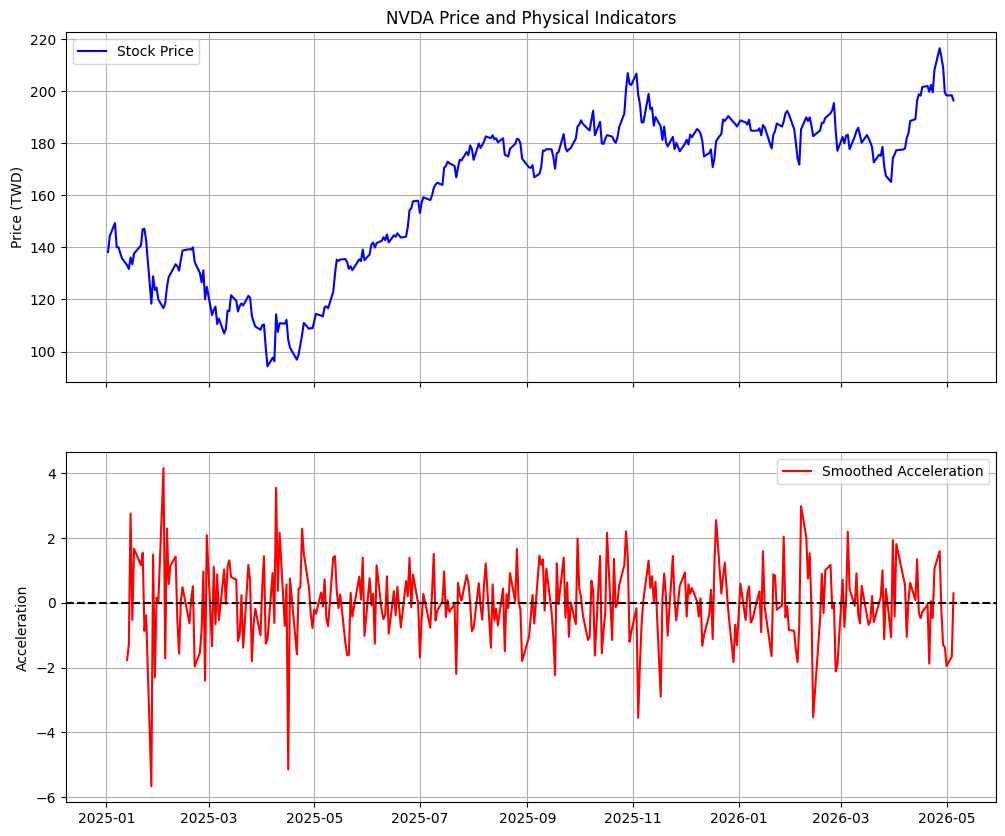

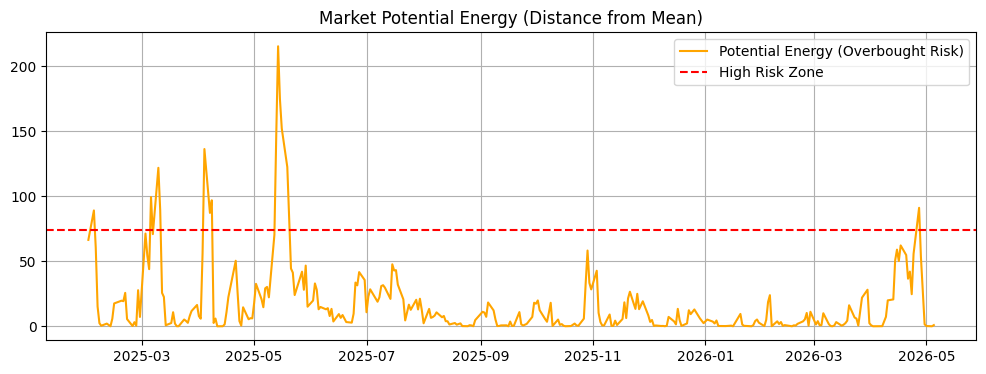


--- 物理老師股市診斷報告 ---
狀態：【穩定加速區】
分析：動力充足且尚未過熱，就像剛起步的賽車，具備上漲潛力。


In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 抓取台股數據 (以台積電 2330 為例)
stock_id = "NVDA"
df = yf.download(stock_id, start="2025-01-01")

# 2. 物理指標計算
# 假設時間間隔 dt = 1 天
# 速度 (Velocity) = 價格的一階差分
df['Velocity'] = df['Close'].diff()

# 加速度 (Acceleration) = 速度的一階差分 (即價格的二階差分)
df['Acceleration'] = df['Velocity'].diff()

# 3. 數據平滑化 (物理上的低通濾波，減少市場雜訊)
# 股市雜訊太多，直接看加速度會很亂，我們用 5 天移動平均來平滑
df['Smooth_Accel'] = df['Acceleration'].rolling(window=5).mean()

# 4. 繪圖與視覺化
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 上圖：收盤價
ax1.plot(df.index, df['Close'], label='Stock Price', color='blue')
ax1.set_title(f'{stock_id} Price and Physical Indicators')
ax1.set_ylabel('Price (TWD)')
ax1.legend()
ax1.grid(True)

# 下圖：平滑後的加速度
# 當加速度 > 0 且由負轉正，在力學上代表「推力增加」
ax2.plot(df.index, df['Smooth_Accel'], label='Smoothed Acceleration', color='red')
ax2.axhline(0, color='black', linestyle='--') # 零軸
ax2.set_ylabel('Acceleration')
ax2.legend()
ax2.grid(True)

plt.show()


# 5. 計算彈性位能 (以 20 日均線為平衡位置)
# 使用 .squeeze() 確保抓出來的是 Series 而不是 DataFrame
close_price = df['Close'].squeeze() 
df_ma20 = close_price.rolling(window=20).mean()

# 位能 U = 1/2 * k * x^2，這裡假設 k=1
# 計算 (股價 - 均線) / 均線 的百分比偏離度
dist_percent = (close_price - df_ma20) / df_ma20 * 100
df['Potential_Energy'] = 0.5 * (dist_percent**2)

# 6. 新增一個圖表呈現位能
plt.figure(figsize=(12, 4))
# 同樣使用 squeeze 確保繪圖數據正確
plt.plot(df.index, df['Potential_Energy'].squeeze(), label='Potential Energy (Overbought Risk)', color='orange')

# 計算風險線 (平均值 + 2倍標準差)
mean_pe = df['Potential_Energy'].mean().item() # .item() 轉為數值
std_pe = df['Potential_Energy'].std().item()
plt.axhline(mean_pe + std_pe * 2, color='red', linestyle='--', label='High Risk Zone')

plt.title('Market Potential Energy (Distance from Mean)')
plt.legend()
plt.grid(True)
plt.show()

# 取得最新的數值
latest_accel = df['Smooth_Accel'].iloc[-1]
latest_pe = df['Potential_Energy'].iloc[-1]
risk_threshold = mean_pe + std_pe * 2

print("\n--- 物理老師股市診斷報告 ---")
if latest_accel > 0 and latest_pe < risk_threshold:
    print("狀態：【穩定加速區】")
    print("分析：動力充足且尚未過熱，就像剛起步的賽車，具備上漲潛力。")
elif latest_accel > 0 and latest_pe >= risk_threshold:
    print("狀態：【極度過熱區】")
    print("分析：雖然動力還在，但彈簧已拉到極限，隨時可能產生劇烈回彈，請勿追高。")
elif latest_accel < 0 and latest_pe < 1.0:
    print("狀態：【能量耗盡區】")
    print("分析：球已經快飛不動了，且就在平衡位置附近，市場進入震盪或觀望。")
else:
    print("狀態：【盤整或反轉中】")
    print("分析：目前訊號較雜，建議結合其他物理指標觀察。")


[*********************100%***********************]  1 of 1 completed


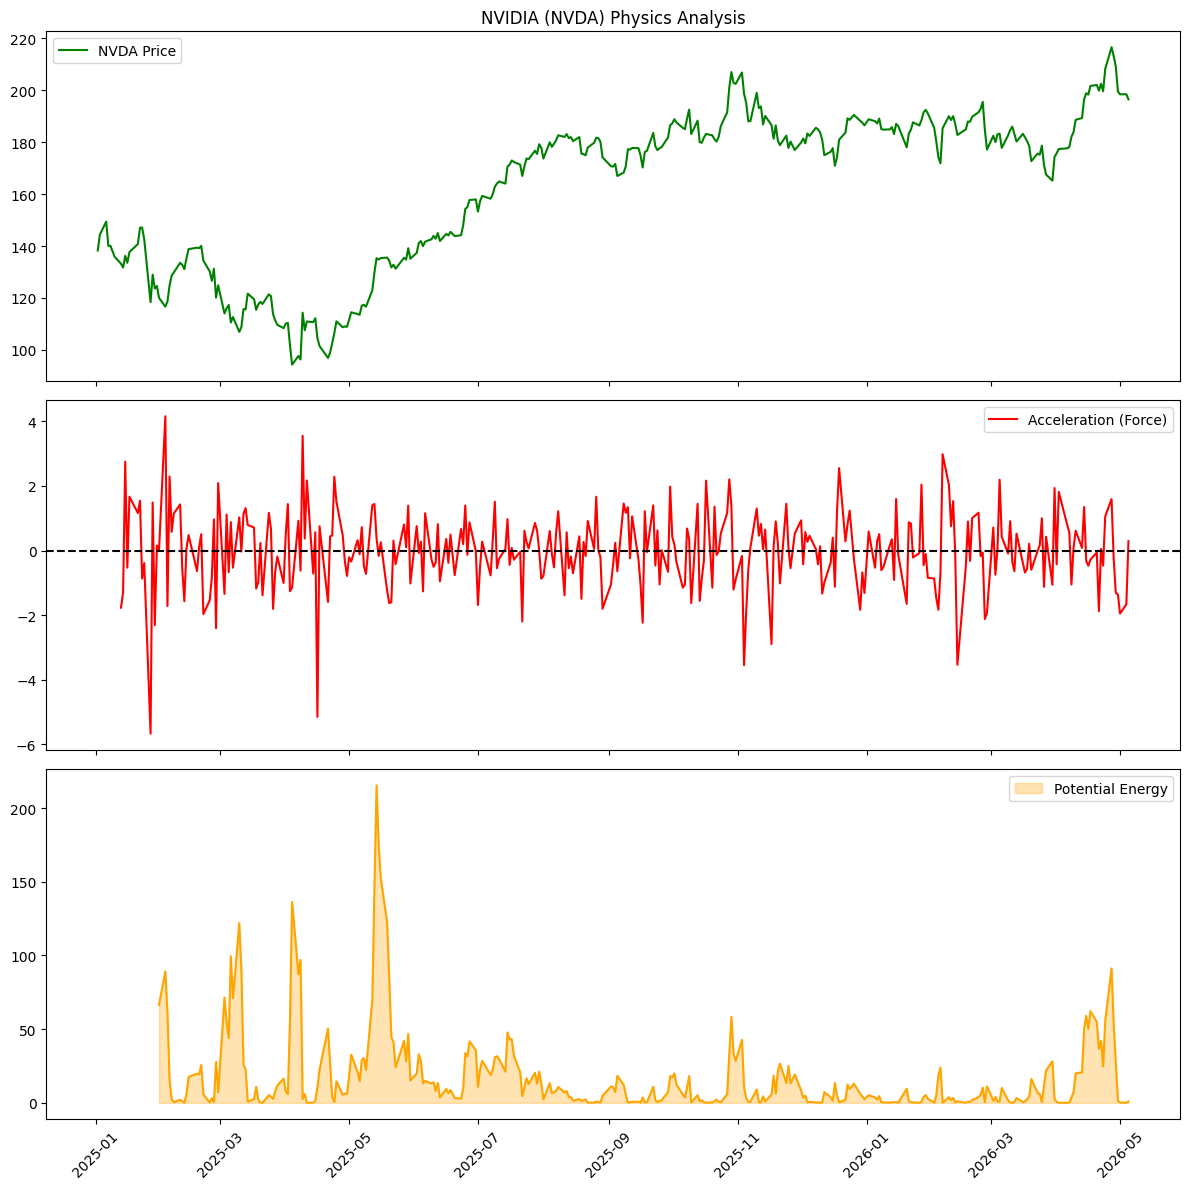

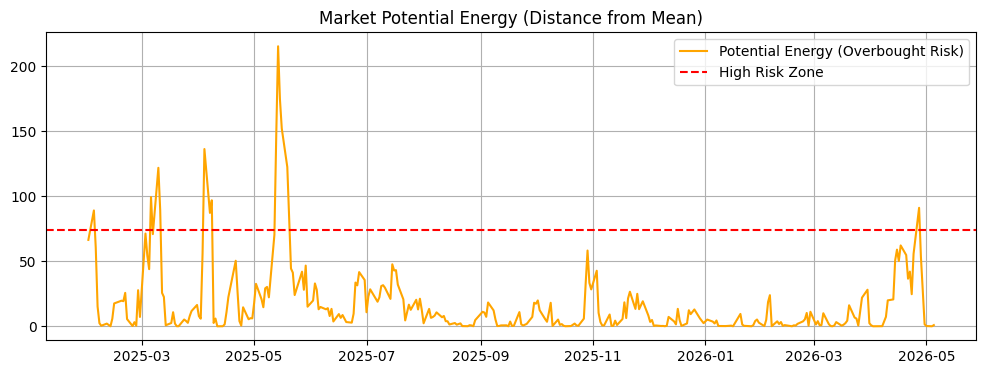

In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 抓取台股數據 (以台積電 2330 為例)
stock_id = "NVDA"
df = yf.download(stock_id, start="2025-01-01")

# 2. 物理指標計算
# 假設時間間隔 dt = 1 天
# --- 1. 重新整理計算邏輯 (確保長度永遠等於 df) ---
close_price = df['Close'].squeeze()

# 速度與加速度 (不刪除 NaN，保持長度一致)
velocity = close_price.diff()
# 加速度：計算後不做 dropna()
accel = velocity.diff().rolling(window=5).mean()

# 位能 (不刪除 NaN)
ma20 = close_price.rolling(window=20).mean()
dist_percent = (close_price - ma20) / ma20 * 100
potential_energy = 0.5 * (dist_percent**2)

# --- 2. 繪圖 (直接傳入 Series，Matplotlib 會自動處理索引對齊) ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# 第一張：股價 (直接傳入 Series)
ax1.plot(close_price.index, close_price.values, label='NVDA Price', color='green')
ax1.set_title('NVIDIA (NVDA) Physics Analysis')
ax1.legend()

# 第二張：加速度
# 直接傳入 accel，它裡面雖然前幾筆是 NaN，但 Matplotlib 會自動跳過，且長度會對齊 index
ax2.plot(accel.index, accel.values, label='Acceleration (Force)', color='red')
ax2.axhline(0, color='black', linestyle='--')
ax2.legend()

# 第三張：位能
# 使用 Series 本身的 index 繪圖
ax3.fill_between(potential_energy.index, potential_energy.values.flatten(), 
                 color='orange', alpha=0.3, label='Potential Energy')
ax3.plot(potential_energy.index, potential_energy.values.flatten(), color='orange')
ax3.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. 計算彈性位能 (以 20 日均線為平衡位置)
# 使用 .squeeze() 確保抓出來的是 Series 而不是 DataFrame
close_price = df['Close'].squeeze() 
df_ma20 = close_price.rolling(window=20).mean()

# 位能 U = 1/2 * k * x^2，這裡假設 k=1
# 計算 (股價 - 均線) / 均線 的百分比偏離度
dist_percent = (close_price - df_ma20) / df_ma20 * 100
df['Potential_Energy'] = 0.5 * (dist_percent**2)

# 6. 新增一個圖表呈現位能
plt.figure(figsize=(12, 4))
# 同樣使用 squeeze 確保繪圖數據正確
plt.plot(df.index, df['Potential_Energy'].squeeze(), label='Potential Energy (Overbought Risk)', color='orange')

# 計算風險線 (平均值 + 2倍標準差)
mean_pe = df['Potential_Energy'].mean().item() # .item() 轉為數值
std_pe = df['Potential_Energy'].std().item()
plt.axhline(mean_pe + std_pe * 2, color='red', linestyle='--', label='High Risk Zone')

plt.title('Market Potential Energy (Distance from Mean)')
plt.legend()
plt.grid(True)
plt.show()


[*********************100%***********************]  1 of 1 completed


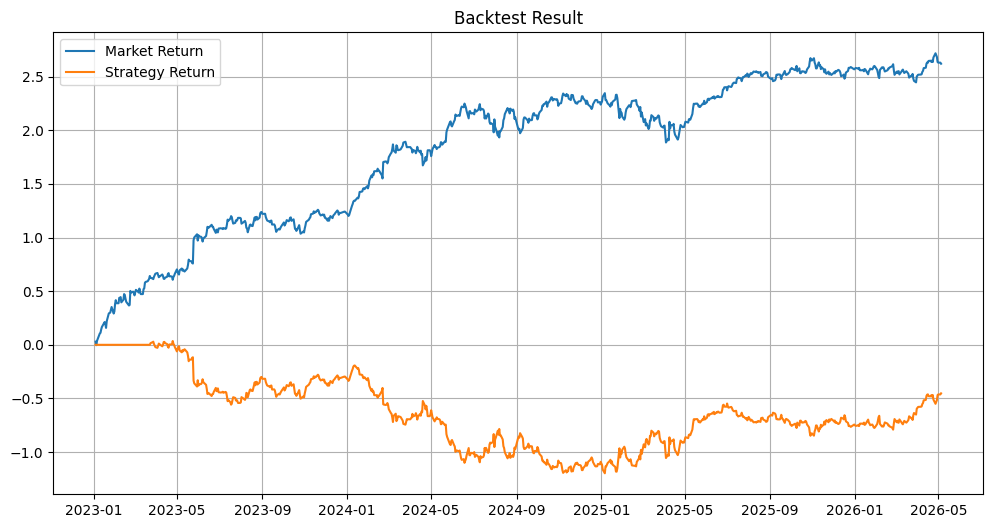

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 抓資料
stock_id = "NVDA"
df = yf.download(stock_id, start="2023-01-01")

close = df['Close'].squeeze()

# 2. 計算 log return（關鍵）
returns = np.log(close / close.shift(1))

# 3. Z-score（取代你原本位能）
mean = close.rolling(20).mean()
std = close.rolling(20).std()
z = (close - mean) / std

# 4. 加速度（趨勢變化）
velocity = returns
accel = velocity.diff().rolling(5).mean()

# 5. 建立策略訊號
signal = pd.Series(0, index=df.index)

# 做多
signal[(z < -2) & (accel > 0)] = 1

# 做空
signal[(z > 2) & (accel < 0)] = -1

# forward fill（持有部位）
position = signal.replace(0, np.nan).ffill().fillna(0)

# 6. 策略報酬
strategy_return = position.shift(1) * returns

# 7. 累積報酬
cum_market = returns.cumsum()
cum_strategy = strategy_return.cumsum()

# 8. 畫圖
plt.figure(figsize=(12,6))
plt.plot(cum_market, label='Market Return')
plt.plot(cum_strategy, label='Strategy Return')
plt.legend()
plt.title("Backtest Result")
plt.grid()
plt.show()

Processing NVDA...


[*********************100%***********************]  1 of 1 completed


Processing AAPL...


[*********************100%***********************]  1 of 1 completed


Processing MSFT...


[*********************100%***********************]  1 of 1 completed


Processing GOOGL...


[*********************100%***********************]  1 of 1 completed


Processing AMZN...


[*********************100%***********************]  1 of 1 completed


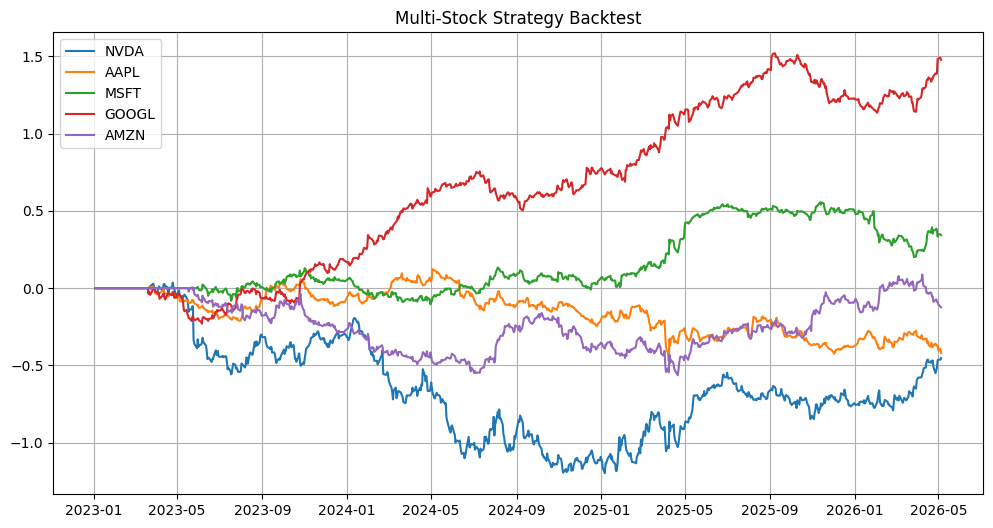

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["NVDA", "AAPL", "MSFT", "GOOGL", "AMZN"]

results = {}

for stock_id in tickers:
    print(f"Processing {stock_id}...")

    df = yf.download(stock_id, start="2023-01-01")
    close = df['Close'].squeeze()

    # log return
    returns = np.log(close / close.shift(1))

    # Z-score
    mean = close.rolling(20).mean()
    std = close.rolling(20).std()
    z = (close - mean) / std

    # acceleration
    velocity = returns
    accel = velocity.diff().rolling(5).mean()

    # signal
    signal = pd.Series(0, index=df.index)
    signal[(z < -2) & (accel > 0)] = 1
    signal[(z > 2) & (accel < 0)] = -1

    # position（修正版）
    position = signal.copy()
    position[signal == 0] = np.nan
    position = position.ffill().fillna(0)

    # strategy return
    strategy_return = position.shift(1) * returns

    # 累積報酬
    cum_strategy = strategy_return.cumsum()

    # 存結果
    results[stock_id] = cum_strategy

# 合併成 DataFrame
result_df = pd.DataFrame(results)

# 畫圖
plt.figure(figsize=(12,6))
for col in result_df.columns:
    plt.plot(result_df[col], label=col)

plt.legend()
plt.title("Multi-Stock Strategy Backtest")
plt.grid()
plt.show()

   Stock  Total Return    Sharpe
3  GOOGL      1.477770  1.561435
2   MSFT      0.342877  0.467383
4   AMZN     -0.124020 -0.127618
0   NVDA     -0.452455 -0.294845
1   AAPL     -0.418637 -0.511237


[*********************100%***********************]  1 of 1 completed


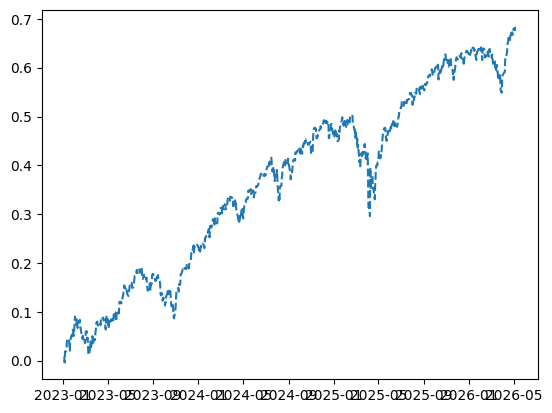

In [10]:
performance = []

for stock in result_df.columns:
    ret = result_df[stock].dropna().diff()

    sharpe = ret.mean() / ret.std() * np.sqrt(252)
    total_return = result_df[stock].iloc[-1]

    performance.append({
        "Stock": stock,
        "Total Return": total_return,
        "Sharpe": sharpe
    })

perf_df = pd.DataFrame(performance)
print(perf_df.sort_values(by="Sharpe", ascending=False))

spy = yf.download("SPY", start="2023-01-01")
spy_return = np.log(spy['Close'] / spy['Close'].shift(1)).cumsum()

plt.plot(spy_return, label="SPY (Market)", linestyle='--')

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


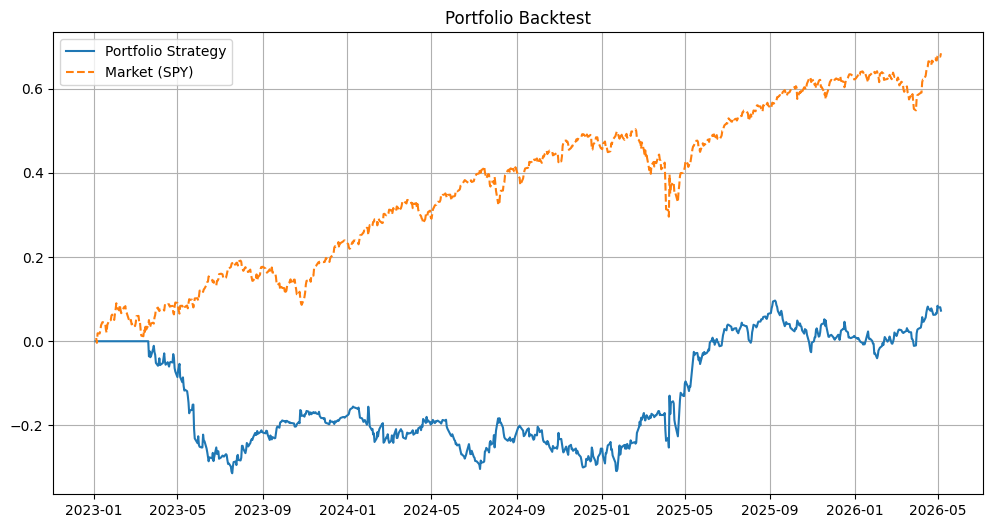

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["NVDA", "AAPL", "MSFT", "GOOGL", "AMZN"]

price_data = yf.download(tickers, start="2023-01-01")['Close']

returns = np.log(price_data / price_data.shift(1))

signals = pd.DataFrame(index=price_data.index, columns=tickers)

# === 逐股票計算訊號 ===
for stock in tickers:
    close = price_data[stock]

    mean = close.rolling(20).mean()
    std = close.rolling(20).std()
    z = (close - mean) / std

    velocity = np.log(close / close.shift(1))
    accel = velocity.diff().rolling(5).mean()

    signal = pd.Series(0, index=close.index)
    signal[(z < -2) & (accel > 0)] = 1
    signal[(z > 2) & (accel < 0)] = -1

    signals[stock] = signal

# === 建立 position ===
positions = signals.copy()
positions[positions == 0] = np.nan
positions = positions.ffill().fillna(0)

# === 權重（核心）===
# 每天平均分配到有持倉的股票
weights = positions.div(positions.abs().sum(axis=1), axis=0)

# === Portfolio Return ===
portfolio_return = (weights.shift(1) * returns).sum(axis=1)

# === 累積報酬 ===
cum_portfolio = portfolio_return.cumsum()

# === 市場基準（SPY）===
spy = yf.download("SPY", start="2023-01-01")
spy_return = np.log(spy['Close'] / spy['Close'].shift(1)).cumsum()

# === 畫圖 ===
plt.figure(figsize=(12,6))
plt.plot(cum_portfolio, label="Portfolio Strategy")
plt.plot(spy_return, label="Market (SPY)", linestyle='--')

plt.legend()
plt.title("Portfolio Backtest")
plt.grid()
plt.show()

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


Sharpe Ratio: 0.189
Max Drawdown: -0.161


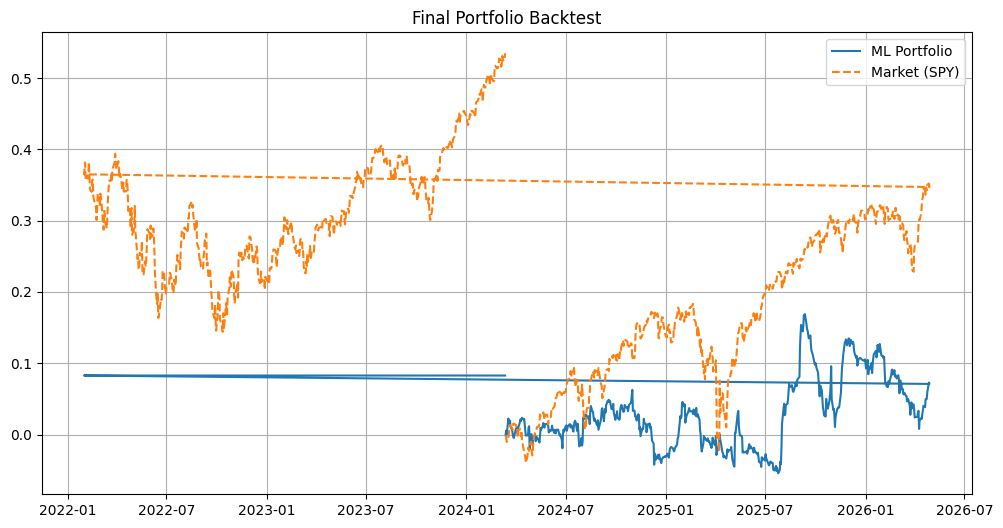

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# === 1. 股票池 ===
tickers = ["NVDA", "AAPL", "MSFT", "GOOGL", "AMZN"]

# === 2. 抓資料 ===
price = yf.download(tickers, start="2022-01-01")['Close']
returns = np.log(price / price.shift(1))

# === 3. Feature Engineering（建立 MultiIndex）===
feature_list = []

for stock in tickers:
    close = price[stock]

    z = (close - close.rolling(20).mean()) / close.rolling(20).std()
    mom = close.pct_change(5)
    vol = returns[stock].rolling(10).std()
    accel = returns[stock].diff().rolling(5).mean()

    df = pd.DataFrame({
        'z': z,
        'mom': mom,
        'vol': vol,
        'accel': accel,
    })

    df['target'] = returns[stock].shift(-5)

    # 👉 關鍵：建立 MultiIndex
    df['date'] = df.index
    df['stock'] = stock
    df.set_index(['date', 'stock'], inplace=True)

    feature_list.append(df)

# 合併
data = pd.concat(feature_list).dropna()

# === 4. Train/Test split（時間順序）===
split = int(len(data) * 0.7)
train = data.iloc[:split]
test = data.iloc[split:]

X_train = train.drop(columns=['target'])
y_train = train['target']

X_test = test.drop(columns=['target'])
y_test = test['target']

# === 5. 模型 ===
model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# === 6. 預測 ===
pred = model.predict(X_test)

test = test.copy()
test['pred'] = pred

# === 7. 轉回 (日期 × 股票) ===
pivot_pred = test['pred'].unstack()
pivot_true = test['target'].unstack()

# === 8. 建立權重（Cross-sectional）===
rank = pivot_pred.rank(axis=1)

q_high = rank.quantile(0.8, axis=1)
q_low = rank.quantile(0.2, axis=1)

long = rank.ge(q_high, axis=0)
short = rank.le(q_low, axis=0)

weights = long.astype(int) - short.astype(int)

# 避免除以0
weights = weights.div(weights.abs().sum(axis=1), axis=0)
weights = weights.fillna(0)

# === 9. 對齊 returns（防炸）===
returns = returns.loc[pivot_pred.index, pivot_pred.columns]

# === 10. Portfolio 回測 ===
strategy_return = (weights.shift(1) * returns).sum(axis=1)

cum_return = strategy_return.cumsum()

# === 11. 市場基準 ===
spy = yf.download("SPY", start="2022-01-01")['Close']
spy_ret = np.log(spy / spy.shift(1))
spy_ret = spy_ret.loc[cum_return.index]
cum_spy = spy_ret.cumsum()

# === 12. 評估 ===
sharpe = strategy_return.mean() / strategy_return.std() * np.sqrt(252)
drawdown = cum_return - cum_return.cummax()

print("Sharpe Ratio:", round(sharpe, 3))
print("Max Drawdown:", round(drawdown.min(), 3))

# === 13. 畫圖 ===
plt.figure(figsize=(12,6))
plt.plot(cum_return, label="ML Portfolio")
plt.plot(cum_spy, label="Market (SPY)", linestyle='--')

plt.title("Final Portfolio Backtest")
plt.legend()
plt.grid()
plt.show()